In [1]:
from Model.AutoEncoder import AutoEncoder
from extractor.data_loader import dataset_loader
import json
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load config file

In [2]:
with open("./config/torch_config.json", "r") as cfg:
    torch_config = json.load(cfg)

# Load Dataset

In [3]:
load_params = torch_config["data_loader"]

In [4]:
dataloader = dataset_loader(
    load_params["file_path"],
    batch_size=load_params["batch_size"],
    mnist_size=load_params["mnist_size"],
    norm_mean=load_params["norm_mean"],
    norm_std=load_params["norm_std"],
)

# Define AutoEncoder

In [5]:
ae_params = torch_config["autoencoder"]
model = AutoEncoder(
    mnist_size=ae_params["mnist_size"],
    hidden_dim=ae_params["hidden_dim"],
    latent_dim=ae_params["latent_dim"],
    neg_slope=ae_params["neg_slope"],
)
model = model.to(device)

# Model architecture

In [ ]:
print("=== AutoEncoder (full) ===")
print(model)
print("\n=== Encoder ===")
print(model.encoder)
print("\n=== Decoder ===")
print(model.decoder)

with torch.no_grad():
    x = torch.randn(2, 1, ae_params["mnist_size"], ae_params["mnist_size"]).to(device)
    z = model.encode(x)
    recon = model.decode(z)
print("\n=== Tensor shapes (batch example, batch_size=2) ===")
print(f"  input x        : {tuple(x.shape)}")
print(f"  latent z       : {tuple(z.shape)}")
print(f"  reconstruction : {tuple(recon.shape)}")

In [6]:
criterion = nn.MSELoss()
lr = torch_config["learning_rate"]
betas_min = torch_config["betas_min"]
betas_max = torch_config["betas_max"]
optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(betas_min, betas_max))

# Model Learning

In [7]:
n_epochs = torch_config["n_epochs"]
log_interval = torch_config["log_interval"]
start_time = time.time()

In [8]:
model.train()
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon = model(imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * imgs.size(0)
    epoch_loss /= len(dataloader.dataset)
    if (epoch + 1) % log_interval == 0 or epoch == 0:
        print(
            f"[Epoch {epoch + 1}/{n_epochs}] [MSE: {epoch_loss:.6f}] [Elapsed: {time.time() - start_time:.2f}s]"
        )

[Epoch 1/30] [MSE: 0.099440] [Elapsed: 7.01s]
[Epoch 2/30] [MSE: 0.042521] [Elapsed: 12.41s]
[Epoch 3/30] [MSE: 0.036559] [Elapsed: 17.65s]
[Epoch 4/30] [MSE: 0.032766] [Elapsed: 22.81s]
[Epoch 5/30] [MSE: 0.030008] [Elapsed: 28.79s]
[Epoch 6/30] [MSE: 0.028036] [Elapsed: 34.00s]
[Epoch 7/30] [MSE: 0.026520] [Elapsed: 39.45s]
[Epoch 8/30] [MSE: 0.025341] [Elapsed: 45.09s]
[Epoch 9/30] [MSE: 0.024420] [Elapsed: 51.09s]
[Epoch 10/30] [MSE: 0.023646] [Elapsed: 56.41s]
[Epoch 11/30] [MSE: 0.022992] [Elapsed: 61.71s]
[Epoch 12/30] [MSE: 0.022449] [Elapsed: 67.20s]
[Epoch 13/30] [MSE: 0.021913] [Elapsed: 72.35s]
[Epoch 14/30] [MSE: 0.021542] [Elapsed: 77.62s]
[Epoch 15/30] [MSE: 0.021185] [Elapsed: 82.70s]
[Epoch 16/30] [MSE: 0.020816] [Elapsed: 87.90s]
[Epoch 17/30] [MSE: 0.020548] [Elapsed: 93.11s]
[Epoch 18/30] [MSE: 0.020272] [Elapsed: 98.73s]
[Epoch 19/30] [MSE: 0.020056] [Elapsed: 105.20s]
[Epoch 20/30] [MSE: 0.019842] [Elapsed: 111.60s]
[Epoch 21/30] [MSE: 0.019652] [Elapsed: 117.70s]

# Result (input vs reconstruction)

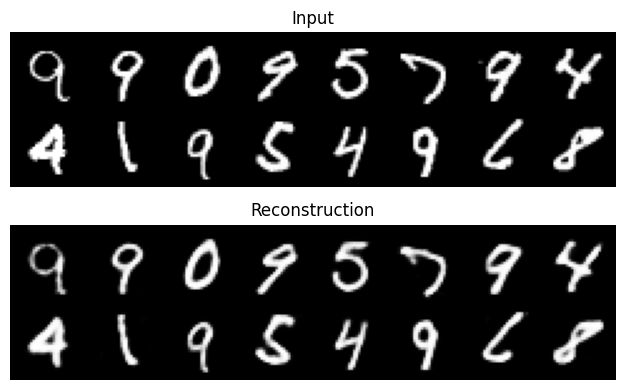

In [9]:
model.eval()
with torch.no_grad():
    sample_imgs, _ = next(iter(dataloader))
    sample_imgs = sample_imgs[:16].to(device)
    recon = model(sample_imgs)

grid_in = make_grid(sample_imgs.cpu(), nrow=8, normalize=True)
grid_out = make_grid(recon.cpu(), nrow=8, normalize=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].imshow(grid_in.permute(1, 2, 0).numpy())
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(grid_out.permute(1, 2, 0).numpy())
axes[1].set_title("Reconstruction")
axes[1].axis("off")
plt.tight_layout()
plt.show()